In [52]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.transforms import functional as F
from torchvision.transforms import ToTensor
import torchvision.models.detection.transform as T
import os
import json
from PIL import Image, UnidentifiedImageError
from torchvision.ops import nms,box_iou
import time
import numpy as np
from collections import defaultdict, Counter
from pycocotools.coco import COCO
from tqdm import tqdm
from pycocotools.cocoeval import COCOeval
import copy
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch.nn as nn
import torch.nn.functional as F 

from torchvision import transforms
from torchvision.transforms import functional as TF  
from torchvision.models.detection.rpn import AnchorGenerator, RegionProposalNetwork, RPNHead
from torchvision.models.detection.transform import GeneralizedRCNNTransform


In [53]:
class MyDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        self.img_dir = os.path.join(root, "images")
        self.label_dir = os.path.join(root, "labels")
        self.imgs = sorted([f for f in os.listdir(self.img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_name = self.imgs[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.rsplit('.', 1)[0] + ".txt")

        try:
            img = Image.open(img_path).convert("RGB")
        except (OSError, UnidentifiedImageError) as e:
            print(f"[Warning] Skipping corrupted image: {img_path} ({e})")
            return self.__getitem__((idx + 1) % len(self))

        width, height = img.size

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    cls, xc, yc, w, h = map(float, line.strip().split())
                    xmin = (xc - w / 2) * width
                    ymin = (yc - h / 2) * height
                    xmax = (xc + w / 2) * width
                    ymax = (yc + h / 2) * height
                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(int(cls) + 1)  # class IDs must start at 1

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
        }

        if self.transforms:
            img_np = np.array(img)
            try:
                if len(boxes) > 0:
                    transformed = self.transforms(image=img_np, bboxes=boxes.tolist(), labels=labels.tolist())
                    img = transformed['image']
                    target["boxes"] = torch.tensor(transformed['bboxes'], dtype=torch.float32)
                    target["labels"] = torch.tensor(transformed['labels'], dtype=torch.int64)
                else:
                    transformed = self.transforms(image=img_np, bboxes=[], labels=[])
                    img = transformed['image']
            except Exception as e:
                print(f"[Warning] Transform failed for idx={idx}, skipping: {e}")
                return self.__getitem__((idx + 1) % len(self))

        return img, target
    

In [54]:
def get_train_transform():
    return A.Compose([
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ], bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels'],
        min_visibility=0.0
    ))
    
def get_val_transform():
    return A.Compose([
        A.NoOp(),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ], bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels'],
        min_visibility=0.0
    ))

In [ ]:
#provide your directory folder for train, valid and test images and annotations
train_root = 'Train'
val_root = 'Val'
test_root = 'Test'

In [56]:
def collate_fn(batch):
    images = []
    targets = []
    for img, target in batch:
        images.append(img)
        targets.append(target)
    return images, targets

train_dataset = MyDataset(train_root, transforms=get_train_transform())
val_dataset = MyDataset(val_root, transforms=get_val_transform())
test_dataset = MyDataset(test_root, transforms=get_val_transform())

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [ ]:
class DynamicDilationRPNHead(RPNHead):
    def __init__(self, in_channels, num_anchors):
        super().__init__(in_channels, num_anchors)

        # In the parallel dilation branches you can grid search for the best dilation. 
        self.dilated1 = nn.Conv2d(in_channels, in_channels, 3, padding=1, dilation=1)
        self.dilated2 = nn.Conv2d(in_channels, in_channels, 3, padding=2, dilation=2)
        self.dilated3 = nn.Conv2d(in_channels, in_channels, 3, padding=3, dilation=3)

        
        self.attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  
            nn.Conv2d(in_channels, in_channels // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 4, 3, 1),  
            nn.Softmax(dim=1)  
        )

        
        self.cls_logits = nn.Conv2d(in_channels, num_anchors, kernel_size=1)
        self.bbox_pred = nn.Conv2d(in_channels, num_anchors * 4, kernel_size=1)

        
        for layer in [
            self.dilated1, self.dilated2, self.dilated3,
            self.cls_logits, self.bbox_pred
        ]:
            nn.init.normal_(layer.weight, std=0.01)
            nn.init.constant_(layer.bias, 0)

    def forward(self, x):
        logits = []
        bbox_reg = []
        for feature in x:
            
            f1 = F.relu(self.dilated1(feature))
            f2 = F.relu(self.dilated2(feature))
            f3 = F.relu(self.dilated3(feature))

            
            weights = self.attn(feature)  
            w1, w2, w3 = weights[:, 0:1], weights[:, 1:2], weights[:, 2:3]

            
            fused = w1 * f1 + w2 * f2 + w3 * f3

            
            logits.append(self.cls_logits(fused))
            bbox_reg.append(self.bbox_pred(fused))

        return logits, bbox_reg

In [ ]:

def get_model(num_classes):
    
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    
   
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    anchor_generator = AnchorGenerator(
        sizes=((32,), (64,), (128,), (256,), (512,)),  
        aspect_ratios=((0.5, 1.0, 2.0),) * 5           
    )

    
    rpn_head = DynamicDilationRPNHead(in_channels=256, num_anchors=anchor_generator.num_anchors_per_location()[0])

    
    model.rpn = RegionProposalNetwork(
        anchor_generator,
        rpn_head,
        fg_iou_thresh=0.7,
        bg_iou_thresh=0.3,
        batch_size_per_image=256,
        positive_fraction=0.5,
        pre_nms_top_n=dict(training=2000, testing=1000),
        post_nms_top_n=dict(training=2000, testing=1000),
        nms_thresh=0.7
    )

    return model

In [ ]:
# Number of classes (include background class i.e 2 classes and 1 background class)
num_classes = 3  
model = get_model(num_classes)
print(model)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [60]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Save model to temporary file
torch.save(model.state_dict(), "temp_model.pth")
model_size_mb = os.path.getsize("temp_model.pth") / (1024 * 1024)
print(f"Model size (MB): {model_size_mb:.2f}")

# Clean up
os.remove("temp_model.pth")

Total parameters: 43,091,169
Trainable parameters: 42,868,769
Model size (MB): 164.89


In [ ]:
def compute_image_map(pred_boxes, pred_labels, pred_scores, gt_boxes, gt_labels, iou_thresholds):
    aps = []

    for iou_thresh in iou_thresholds:
        
        if len(pred_boxes) == 0:
            if len(gt_boxes) == 0:
                aps.append(1.0)  
            else:
                aps.append(0.0)  
            continue

        
        sorted_idx = pred_scores.argsort(descending=True)
        pred_boxes = pred_boxes[sorted_idx]
        pred_labels = pred_labels[sorted_idx]

        matched_gt = set()
        tp, fp = [], []

        for i in range(len(pred_boxes)):
            box = pred_boxes[i].unsqueeze(0)
            label = pred_labels[i]

            if len(gt_boxes) == 0:
                tp.append(0)
                fp.append(1)
                continue

            ious = box_iou(box, gt_boxes)[0]  
            max_iou, max_idx = ious.max(0)

            if max_iou.item() >= iou_thresh and max_idx.item() not in matched_gt and label == gt_labels[max_idx.item()]:
                tp.append(1)
                fp.append(0)
                matched_gt.add(max_idx.item())
            else:
                tp.append(0)
                fp.append(1)

        tp_cum = torch.cumsum(torch.tensor(tp), dim=0)
        fp_cum = torch.cumsum(torch.tensor(fp), dim=0)

        recalls = tp_cum / (len(gt_boxes) + 1e-6)
        precisions = tp_cum / (tp_cum + fp_cum + 1e-6)

        
        ap = 0.0
        for t in np.linspace(0, 1, 11):
            mask = recalls >= t
            p = precisions[mask].max().item() if mask.any() else 0.0
            ap += p / 11.0

        aps.append(ap)

    return sum(aps) / len(aps)

In [ ]:

torch.cuda.empty_cache()
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)


params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

num_epochs = 20
best_map = 0.0
train_losses = []
val_maps = []
iou_thresholds = [x / 100.0 for x in range(50, 100, 5)]  # IoUs: 0.5 to 0.95


for epoch in range(num_epochs):
    start_time = time.time()
    print(f"\nEpoch {epoch + 1}/{num_epochs}\n{'-' * 50}")

  
    model.train()
    total_loss = 0.0

    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Training Loss: {avg_loss:.4f}")
    lr_scheduler.step()

    
    model.eval()
    image_maps = []

    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output['boxes'].cpu()
                pred_labels = output['labels'].cpu()
                pred_scores = output['scores'].cpu()
                gt_boxes = target['boxes'].cpu()
                gt_labels = target['labels'].cpu()

                
                if len(gt_boxes) == 0:
                    if len(pred_boxes) == 0:
                        image_maps.append(1.0)  
                    else:
                        image_maps.append(0.0)  
                        print("[Val]  False positive on negative image.")
                else:
                    mAP = compute_image_map(pred_boxes, pred_labels, pred_scores,
                                            gt_boxes, gt_labels, iou_thresholds)
                    image_maps.append(mAP)

    mean_map = sum(image_maps) / len(image_maps)
    val_maps.append(mean_map)
    print(f"Validation mAP@[.5:.95]: {mean_map:.4f}")

    
    if mean_map > best_map:
        best_map = mean_map
        torch.save(model.state_dict(), "best_model.pth")
        print(f" Saved new best model with mAP: {mean_map:.4f}")

    print(f" Epoch time: {time.time() - start_time:.2f} seconds")

print("\n Training complete.")


Epoch 1/20
--------------------------------------------------
Training Loss: 0.7014
Validation mAP@[.5:.95]: 0.3781
 Saved new best model with mAP: 0.3781
 Epoch time: 209.13 seconds

Epoch 2/20
--------------------------------------------------
Training Loss: 0.5773
Validation mAP@[.5:.95]: 0.5025
 Saved new best model with mAP: 0.5025
 Epoch time: 148.05 seconds

Epoch 3/20
--------------------------------------------------
Training Loss: 0.5082
Validation mAP@[.5:.95]: 0.5014
 Epoch time: 147.07 seconds

Epoch 4/20
--------------------------------------------------
Training Loss: 0.3927
Validation mAP@[.5:.95]: 0.5619
 Saved new best model with mAP: 0.5619
 Epoch time: 147.00 seconds

Epoch 5/20
--------------------------------------------------
Training Loss: 0.3607
Validation mAP@[.5:.95]: 0.5684
 Saved new best model with mAP: 0.5684
 Epoch time: 146.71 seconds

Epoch 6/20
--------------------------------------------------
Training Loss: 0.3398
Validation mAP@[.5:.95]: 0.5664
 E

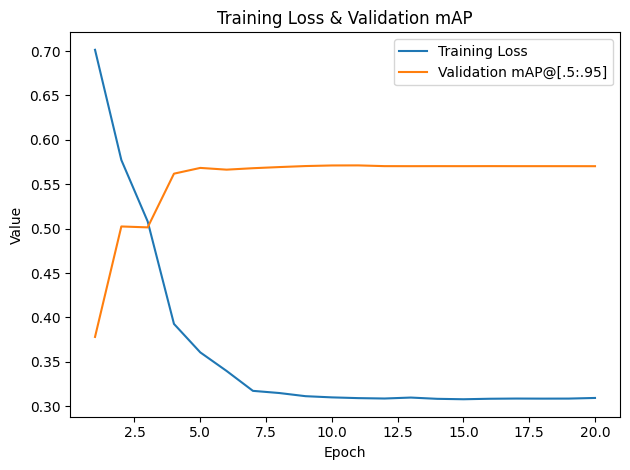

In [63]:
epochs = list(range(1, num_epochs + 1))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_maps, label='Validation mAP@[.5:.95]')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss & Validation mAP')
plt.legend()
plt.tight_layout()
plt.savefig("training_curve.png")
plt.show()

In [64]:
class_names = {
    1: "Grasshopper",
    2: "Fallarmyworm"
}

In [ ]:

best_model_path = 'best_model.pth'
score_threshold = 0.7
image_dir = os.path.join(test_root, "images")
label_dir = os.path.join(test_root, "labels")


model.load_state_dict(torch.load(best_model_path))
model.eval()
device = next(model.parameters()).device
model.to(device)


def calculate_ap(recall, precision):
    recall = np.concatenate(([0.0], recall, [1.0]))
    precision = np.concatenate(([0.0], precision, [0.0]))
    for i in range(len(precision) - 1, 0, -1):
        precision[i - 1] = max(precision[i - 1], precision[i])
    indices = np.where(recall[1:] != recall[:-1])[0]
    return np.sum((recall[indices + 1] - recall[indices]) * precision[indices + 1])


iou_thresholds = np.arange(0.5, 1.0, 0.05)
average_precisions = defaultdict(lambda: defaultdict(list))
classwise_tp_fp_fn = defaultdict(lambda: {'TP': 0, 'FP': 0, 'FN': 0})
failure_bbox_counts = defaultdict(lambda: {'FP': 0, 'FN': 0})
total_gt_boxes_per_class = defaultdict(int)

total_true_positives = 0
total_false_positives = 0
total_false_negatives = 0
total_inference_time = 0
num_images = 0

image_files = sorted([f for f in os.listdir(image_dir) if f.endswith((".jpg", ".jpeg", ".png"))])

for image_name in image_files:
    image_path = os.path.join(image_dir, image_name)
    label_path = os.path.join(label_dir, os.path.splitext(image_name)[0] + ".txt")

    image = Image.open(image_path).convert("RGB")
    image_tensor = TF.to_tensor(image).unsqueeze(0).to(device)
    width, height = image.size

    gt_boxes = []
    gt_classes = []
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                cls, xc, yc, w, h = map(float, line.strip().split())
                x_min = (xc - w / 2) * width
                y_min = (yc - h / 2) * height
                x_max = (xc + w / 2) * width
                y_max = (yc + h / 2) * height
                gt_boxes.append([x_min, y_min, x_max, y_max])
                gt_classes.append(int(cls) + 1)

    gt_boxes = torch.tensor(gt_boxes, dtype=torch.float32)
    gt_classes = torch.tensor(gt_classes, dtype=torch.int64)
    for cls in gt_classes.tolist():
        total_gt_boxes_per_class[cls] += 1

    start_time = time.time()
    with torch.no_grad():
        predictions = model(image_tensor)[0]
    end_time = time.time()

    total_inference_time += (end_time - start_time)
    num_images += 1

    pred_boxes = predictions["boxes"].cpu()
    pred_classes = predictions["labels"].cpu()
    pred_scores = predictions["scores"].cpu()

    keep = pred_scores > score_threshold
    pred_boxes = pred_boxes[keep]
    pred_classes = pred_classes[keep]
    pred_scores = pred_scores[keep]

    for iou_threshold in iou_thresholds:
        classwise_true_positives = defaultdict(list)
        classwise_false_positives = defaultdict(list)
        classwise_scores = defaultdict(list)
        classwise_num_gt = defaultdict(int)
        matched_gt = set()

        for i, pred_box in enumerate(pred_boxes):
            pred_class = pred_classes[i].item()
            best_iou = 0
            best_gt_idx = -1
            for j, gt_box in enumerate(gt_boxes):
                gt_class = gt_classes[j].item()
                if j in matched_gt or pred_class != gt_class:
                    continue
                iou = box_iou(pred_box.unsqueeze(0), gt_box.unsqueeze(0)).item()
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

            classwise_scores[pred_class].append(pred_scores[i].item())
            if best_iou >= iou_threshold:
                classwise_true_positives[pred_class].append(1)
                classwise_false_positives[pred_class].append(0)
                matched_gt.add(best_gt_idx)
            else:
                classwise_true_positives[pred_class].append(0)
                classwise_false_positives[pred_class].append(1)

        for gt_class in gt_classes.tolist():
            classwise_num_gt[gt_class] += 1

        for class_id in classwise_true_positives:
            tp = np.array(classwise_true_positives[class_id])
            fp = np.array(classwise_false_positives[class_id])
            scores = np.array(classwise_scores[class_id])
            if classwise_num_gt[class_id] == 0:
                continue
            sorted_idx = np.argsort(-scores)
            tp = tp[sorted_idx]
            fp = fp[sorted_idx]
            tp_cumsum = np.cumsum(tp)
            fp_cumsum = np.cumsum(fp)
            recall = tp_cumsum / (classwise_num_gt[class_id] + 1e-6)
            precision = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
            ap = calculate_ap(recall, precision)
            average_precisions[class_id][iou_threshold].append(ap)

    matched_gt_05 = set()
    for i, pred_box in enumerate(pred_boxes):
        pred_class = pred_classes[i].item()
        best_iou = 0
        best_gt_idx = -1
        for j, gt_box in enumerate(gt_boxes):
            if j in matched_gt_05 or pred_class != gt_classes[j].item():
                continue
            iou = box_iou(pred_box.unsqueeze(0), gt_box.unsqueeze(0)).item()
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        if best_iou >= 0.5:
            total_true_positives += 1
            matched_gt_05.add(best_gt_idx)
            classwise_tp_fp_fn[pred_class]['TP'] += 1
        else:
            total_false_positives += 1
            classwise_tp_fp_fn[pred_class]['FP'] += 1
            failure_bbox_counts[pred_class]['FP'] += 1

    for j, gt_class in enumerate(gt_classes):
        if j not in matched_gt_05:
            class_id = gt_class.item()
            classwise_tp_fp_fn[class_id]['FN'] += 1
            failure_bbox_counts[class_id]['FN'] += 1
    total_false_negatives += len(gt_boxes) - len(matched_gt_05)


map_50 = np.mean([np.mean(average_precisions[c][0.5]) for c in average_precisions if 0.5 in average_precisions[c]])
map_50_95 = np.mean([
    np.mean([np.mean(average_precisions[c][iou]) for iou in iou_thresholds if iou in average_precisions[c]])
    for c in average_precisions
])

precision = total_true_positives / (total_true_positives + total_false_positives + 1e-6)
recall = total_true_positives / (total_true_positives + total_false_negatives + 1e-6)
f1_score = 2 * precision * recall / (precision + recall + 1e-6)
avg_latency = total_inference_time / num_images if num_images > 0 else 0

print(f"\n--- Overall Metrics ---")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print(f"mAP@50: {map_50:.4f}")
print(f"mAP@50:95: {map_50_95:.4f}")
print(f"Total Latency: {total_inference_time:.2f} s")
print(f"Average Latency per Image: {avg_latency:.4f} s")

print("\n--- Per-Class Metrics ---")
for class_id in sorted(classwise_tp_fp_fn.keys()):
    tp = classwise_tp_fp_fn[class_id]['TP']
    fp = classwise_tp_fp_fn[class_id]['FP']
    fn = classwise_tp_fp_fn[class_id]['FN']
    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6) if (precision + recall) > 0 else 0
    ap_50 = np.mean(average_precisions[class_id][0.5]) if 0.5 in average_precisions[class_id] else 0
    ap_5095 = np.mean([
        np.mean(average_precisions[class_id][iou]) for iou in iou_thresholds if iou in average_precisions[class_id]
    ])
    class_name = class_names.get(class_id, f"Class {class_id}")
    print(f"{class_name}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, mAP@50={ap_50:.4f}, mAP@50:95={ap_5095:.4f}")


--- Overall Metrics ---
Precision: 0.8069
Recall: 0.7513
F1 Score: 0.7781
mAP@50: 0.7996
mAP@50:95: 0.5442
Total Latency: 9.22 s
Average Latency per Image: 0.0330 s

--- Per-Class Metrics ---
Grasshopper: Precision=0.7155, Recall=0.8049, F1=0.7576, mAP@50=0.8046, mAP@50:95=0.5569
Fallarmyworm: Precision=0.9034, Recall=0.7117, F1=0.7961, mAP@50=0.7946, mAP@50:95=0.5314
